## Actividad N° 1.2	Limpieza de datos 
> 25-03-2026

In [ ]:
# Prompt_celda_01: Cargar el archivo Notas_de_estudiantes.csv en un dataframe

import pandas as pd

df = pd.read_csv('../edads_de_estudiantes.csv')
df

# Metodologia utilizada
1.	Diagnóstico inicial: df.info(), df.isna().sum(), df.describe(), df.duplicated().sum().

In [80]:
df.info() # El tipo de dato de 'nota' es object, lo que indica que hay valores no numéricos o mezclados. 
# Esto puede causar problemas para análisis posteriores, por lo que es necesario convertirlo a un tipo numérico y 
# manejar los errores adecuadamente.

<class 'pandas.DataFrame'>
Index: 180 entries, 0 to 199
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   nombre    180 non-null    str    
 1   apellido  180 non-null    str    
 2   semestre  180 non-null    str    
 3   edad      180 non-null    float64
 4   nota      180 non-null    float64
dtypes: float64(2), str(3)
memory usage: 8.4 KB


# Analisis df.info() : 
1) la tabla contiene 5 campos
2) Total de registros son 200
3) existen datos nulos en todos los campos (cantidad 47)
4) todos los campos son de tipo string

In [81]:
df.describe()

,edad,nota
count,180.000000,180.000000
mean,24.616667,4.581167
std,6.225084,1.495860
min,17.000000,0.000000
25%,22.000000,4.967500
50%,24.000000,5.285000
75%,26.000000,5.285000
max,66.000000,7.000000


In [82]:
# Celda auxiliar para revisar describe de forma compacta
summary = df.describe(include='all').transpose()
print(summary.to_string())

          count unique           top freq       mean       std   min     25%    50%    75%   max
nombre      180     71    sin_nombre   13        NaN       NaN   NaN     NaN    NaN    NaN   NaN
apellido    180     75  sin_apellido    9        NaN       NaN   NaN     NaN    NaN    NaN   NaN
semestre    180     14             3   47        NaN       NaN   NaN     NaN    NaN    NaN   NaN
edad      180.0    NaN           NaN  NaN  24.616667  6.225084  17.0    22.0   24.0   26.0  66.0
nota      180.0    NaN           NaN  NaN   4.581167   1.49586   0.0  4.9675  5.285  5.285   7.0


# Analisis df.describe() : 
- nombre:
    count = 191: hay 9 valores faltantes
    unique = 72: tienes 72 nombres distintos
    top = Fernando, freq = 12: Fernando aparece 12 veces.
    > Accion en archivo excel:
    - Con los nulos de los nombres se completo con texto "sin_nombre"
    - Se aplica metodo de duplicados 

- apellido:
    count = 196: hay 4 faltantes
    unique = 76
    top = Vargas, freq = 9

- semestre:
    count = 184: hay 16 faltantes
    unique = 27: demasiadas formas distintas para algo que debería tener pocos valores (ej: 1, 2, 3...)
    top = 4, freq = 18

- edad:
    count = 190: hay 10 faltantes
    unique = 34
    top = 24, freq = 16
    Ojo: edad salió como texto, no como número, por eso no aparecen media, min, max, etc.

- nota:
    count = 192: hay 8 faltantes
    unique = 153: mucha variación de formato
    top = 999, freq = 4: valor muy sospechoso como nota, posible error o outlier

In [ ]:
df.duplicated().sum() # No hay filas duplicadas

# existian 20 registros duplicados, pero se eliminaron con drop_duplicates()

np.int64(0)

In [8]:
df.drop_duplicates(inplace=True) # Eliminar filas duplicadas, aunque no hay ninguna en este caso

In [84]:
df.isna().sum() # No hay valores faltantes, pero si los hubiera, se podrían manejar con df.fillna() o df.dropna() dependiendo del caso.

nombre      0
apellido    0
semestre    0
edad        0
nota        0
dtype: int64

In [14]:
semestre_moda = df["semestre"].mode()[0]
df["semestre"] = df["semestre"].fillna(semestre_moda) # Rellenar valores faltantes en "semestre" con la moda, 
# aunque no hay ninguno en este caso


# Primero limpiar y convertir a numerico si es texto
df["nota"] = pd.to_numeric(df["nota"].astype(str).str.replace(",", "."), errors="coerce")

# Luego imputar con mediana
nota_mediana = df["nota"].median()
df["nota"] = df["nota"].fillna(nota_mediana)



In [58]:
# Mostrar solo filas con nulos en nombre o apellido
df[df['nombre'].isna() | df['apellido'].isna()]

,nombre,apellido,semestre,edad,nota


In [57]:
# Reemplazar nulos o vacíos en nombre/apellido
df["nombre"] = (
    df["nombre"]
    .replace(r"^\s*$", pd.NA, regex=True)
    .fillna("sin_nombre")
)

df["apellido"] = (
    df["apellido"]
    .replace(r"^\s*$", pd.NA, regex=True)
    .fillna("sin_apellido")
)

In [85]:
# Resumen compacto para analisis
print('=== Describe general (include=all) ===')
print(df.describe(include='all').transpose()[['count','unique','top','freq']].to_string())

print('\n=== Describe numerico (edad, nota) ===')
print(df[['edad','nota']].describe().to_string())

=== Describe general (include=all) ===
          count unique           top freq
nombre      180     71    sin_nombre   13
apellido    180     75  sin_apellido    9
semestre    180     14             3   47
edad      180.0    NaN           NaN  NaN
nota      180.0    NaN           NaN  NaN

=== Describe numerico (edad, nota) ===
             edad        nota
count  180.000000  180.000000
mean    24.616667    4.581167
std      6.225084    1.495860
min     17.000000    0.000000
25%     22.000000    4.967500
50%     24.000000    5.285000
75%     26.000000    5.285000
max     66.000000    7.000000


In [25]:
# Transformar 'nota' a numerico
df['nota'] = pd.to_numeric(df['nota'].astype(str).str.replace(',', '.', regex=False).str.replace('"', '', regex=False).str.strip(), errors='coerce')

# Imputar mediana en nulos y outliers (fuera de 0 a 7)
df['nota'] = df['nota'].where(df['nota'].between(0, 7)).fillna(df['nota'].where(df['nota'].between(0, 7)).median())

In [55]:
# Analisis estadistico actualizado
print('=== describe(include=all) ===')
print(df.describe(include='all').transpose()[['count','unique','top','freq']].to_string())

print('\n=== describe numerico ===')
print(df.select_dtypes(include='number').describe().to_string())

=== describe(include=all) ===
          count unique           top freq
nombre      180     71    sin_nombre   13
apellido    180     75  sin_apellido    9
semestre    180     14             3   47
edad      180.0    NaN           NaN  NaN
nota      180.0    NaN           NaN  NaN

=== describe numerico ===
        edad        nota
count  180.0  180.000000
mean     7.0    4.581167
std      0.0    1.495860
min      7.0    0.000000
25%      7.0    4.967500
50%      7.0    5.285000
75%      7.0    5.285000
max      7.0    7.000000


In [78]:
# Restaurar y limpiar 'edad' desde el archivo fuente (evita corrupcion por ejecuciones anteriores)
fuente_edad = pd.read_csv('../Notas_de_estudiantes.csv', sep=';')

# Alinear por indice original (reindex devuelve NaN para indices fuera de rango)
edad_raw = pd.to_numeric(
    fuente_edad['edad'].reindex(df.index).astype(str).str.replace(',', '.', regex=False).str.strip(),
    errors='coerce'
)

# Imputar mediana en nulos y outliers (fuera de 14 a 80)
edad_valida_mask = edad_raw.between(14, 80)
edad_mediana = edad_raw[edad_valida_mask].median()
df['edad'] = edad_raw.where(edad_valida_mask).fillna(edad_mediana)

print('edad min/max:', df['edad'].min(), df['edad'].max())
print('Registros validos (14-80):', edad_valida_mask.sum())
print('Mediana aplicada:', edad_mediana)


edad min/max: 17.0 66.0
Registros validos (14-80): 158
Mediana aplicada: 24.0


In [60]:
df["semestre"].value_counts(dropna=False) # El semestre 1 es el más común, pero hay una cantidad significativa de registros 
# sin semestre asignado (NaN).

semestre
3     47
4     28
6     15
5     15
1     14
9     13
2     12
8     11
10    11
7     10
 8     1
 6     1
 5     1
 4     1
Name: count, dtype: int64

In [ ]:
# Reemplazar outliers de 'semestre' con la mediana
sem_num = pd.to_numeric(df['semestre'], errors='coerce')
sem_valido = sem_num.between(1, 10)

outliers_semestre = df.loc[~sem_valido, ['nombre', 'apellido', 'semestre']]
print('Outliers detectados en semestre:', len(outliers_semestre))
display(outliers_semestre.head(20))

mediana_semestre = int(round(sem_num[sem_valido].median()))
df.loc[~sem_valido, 'semestre'] = str(mediana_semestre)

print('Mediana aplicada a outliers:', mediana_semestre)
print(df['semestre'].value_counts(dropna=False).head(10))

DASHBOARD EJECUTIVO - RENDIMIENTO ESTUDIANTIL


,Metrica,Valor
0,Total estudiantes,180
1,Nota promedio,4.58
2,Nota mediana,5.28
3,Tasa aprobacion (nota >= 4.0),77.8%
4,Tasa riesgo academico (nota < 4.0),22.2%
5,Edad mediana,24.0
6,Semestre mas frecuente,3


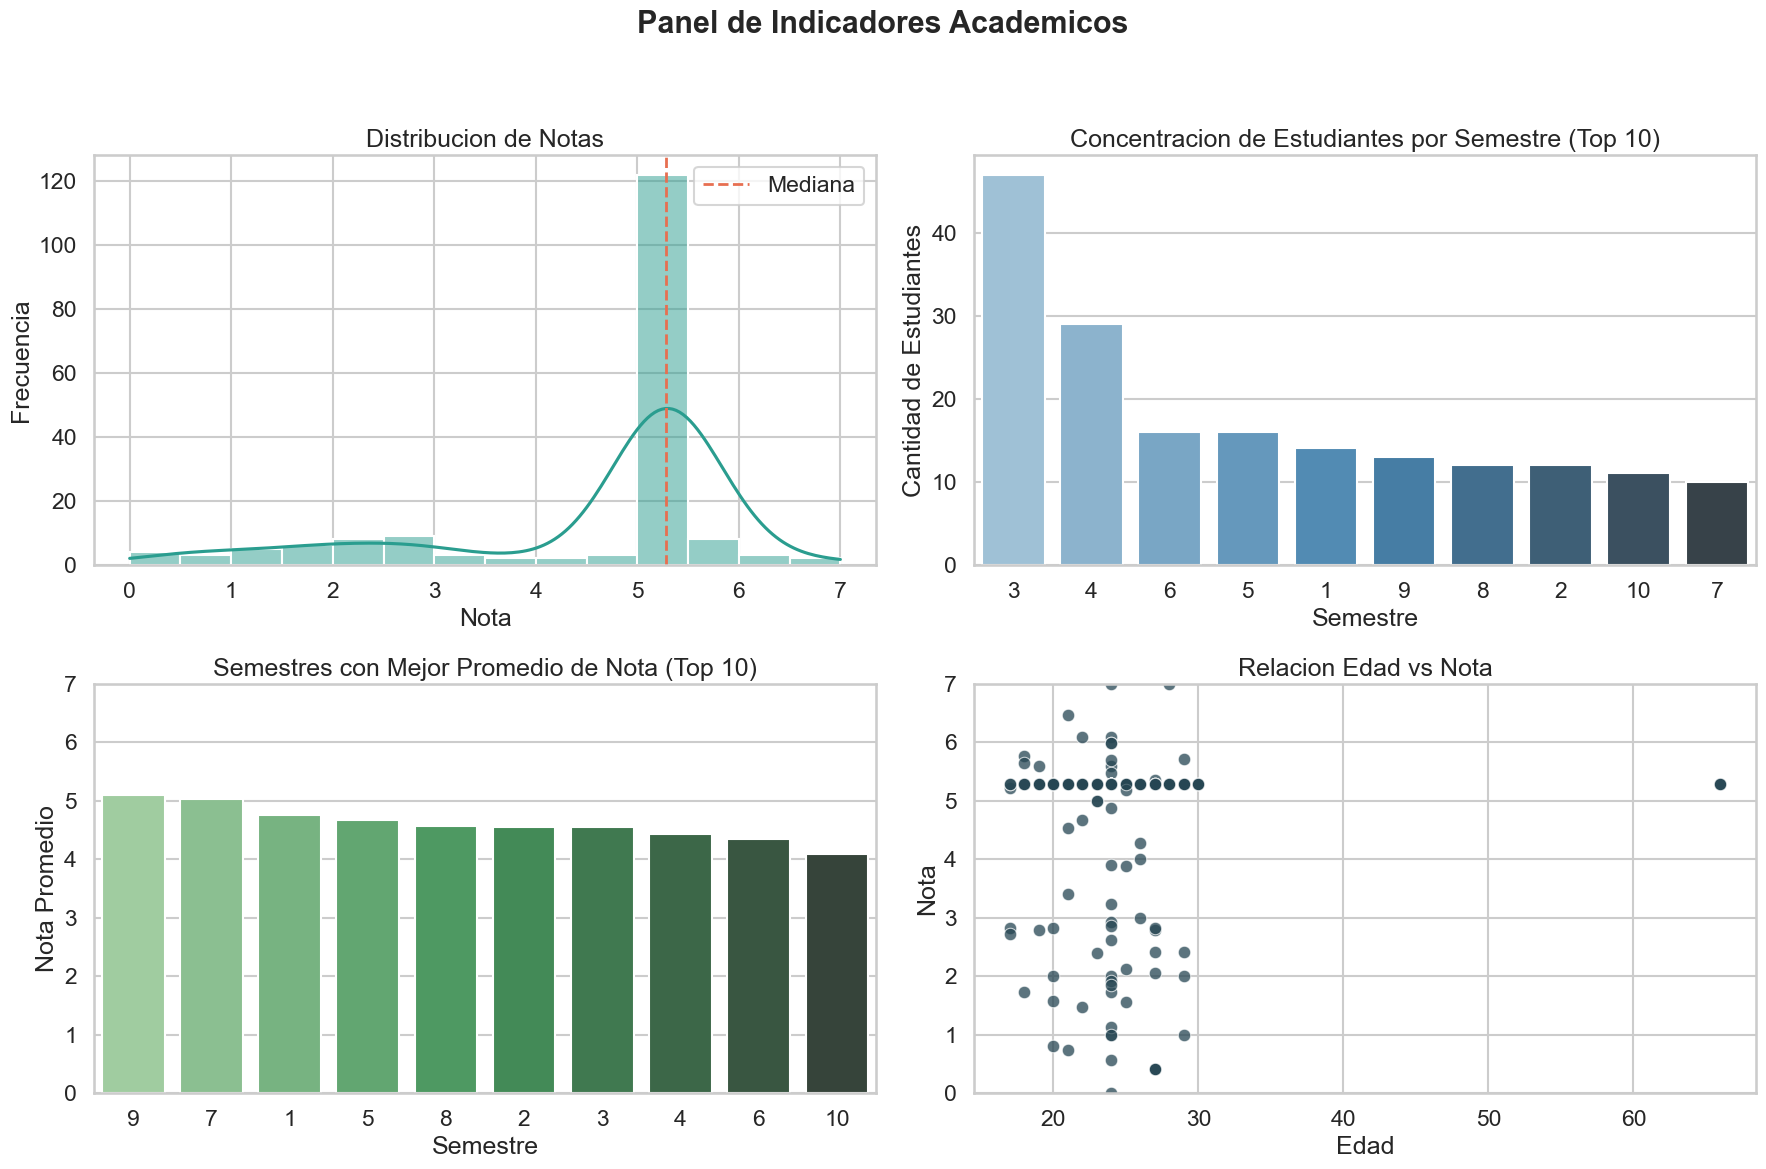

In [86]:
# Dashboard ejecutivo para toma de decisiones
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Copia de trabajo para visualizacion
dash = df.copy()

# Estandarizacion basica para metricas
dash['nota'] = pd.to_numeric(dash['nota'], errors='coerce')
dash['edad'] = pd.to_numeric(dash['edad'], errors='coerce')
dash['semestre'] = dash['semestre'].astype(str).str.strip()

# Rangos operativos
nota_valida = dash['nota'].between(0, 7)
edad_valida = dash['edad'].between(14, 80)

# KPI principales
kpi = pd.DataFrame({
    'Metrica': [
        'Total estudiantes',
        'Nota promedio',
        'Nota mediana',
        'Tasa aprobacion (nota >= 4.0)',
        'Tasa riesgo academico (nota < 4.0)',
        'Edad mediana',
        'Semestre mas frecuente'
    ],
    'Valor': [
        len(dash),
        round(dash.loc[nota_valida, 'nota'].mean(), 2),
        round(dash.loc[nota_valida, 'nota'].median(), 2),
        f"{(dash.loc[nota_valida, 'nota'].ge(4).mean() * 100):.1f}%",
        f"{(dash.loc[nota_valida, 'nota'].lt(4).mean() * 100):.1f}%",
        round(dash.loc[edad_valida, 'edad'].median(), 0),
        dash['semestre'].mode().iat[0] if not dash['semestre'].mode().empty else 'N/A'
    ]
})

print('DASHBOARD EJECUTIVO - RENDIMIENTO ESTUDIANTIL')
display(kpi)

# Preparacion de datos para graficos
sem_count = (
    dash['semestre']
    .value_counts()
    .head(10)
    .reset_index()
)
sem_count.columns = ['semestre', 'estudiantes']

prom_sem = (
    dash.loc[nota_valida]
    .groupby('semestre', as_index=False)['nota']
    .mean()
    .sort_values('nota', ascending=False)
    .head(10)
)

# Estilo visual
sns.set_theme(style='whitegrid', context='talk')
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Panel de Indicadores Academicos', fontsize=22, fontweight='bold')

# 1) Distribucion de notas
sns.histplot(dash.loc[nota_valida, 'nota'], bins=14, kde=True, color='#2a9d8f', ax=axes[0, 0])
axes[0, 0].axvline(dash.loc[nota_valida, 'nota'].median(), color='#e76f51', linestyle='--', linewidth=2, label='Mediana')
axes[0, 0].set_title('Distribucion de Notas')
axes[0, 0].set_xlabel('Nota')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()

# 2) Estudiantes por semestre (Top 10)
sns.barplot(data=sem_count, x='semestre', y='estudiantes', hue='semestre', palette='Blues_d', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Concentracion de Estudiantes por Semestre (Top 10)')
axes[0, 1].set_xlabel('Semestre')
axes[0, 1].set_ylabel('Cantidad de Estudiantes')

# 3) Promedio de nota por semestre (Top 10)
sns.barplot(data=prom_sem, x='semestre', y='nota', hue='semestre', palette='Greens_d', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Semestres con Mejor Promedio de Nota (Top 10)')
axes[1, 0].set_xlabel('Semestre')
axes[1, 0].set_ylabel('Nota Promedio')
axes[1, 0].set_ylim(0, 7)

# 4) Relacion edad-nota
sns.scatterplot(data=dash.loc[nota_valida & edad_valida], x='edad', y='nota', color='#264653', alpha=0.75, ax=axes[1, 1])
axes[1, 1].set_title('Relacion Edad vs Nota')
axes[1, 1].set_xlabel('Edad')
axes[1, 1].set_ylabel('Nota')
axes[1, 1].set_ylim(0, 7)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [79]:
# Diagnostico rapido del filtro edad vs nota
print('edad min/max:', df['edad'].min(), df['edad'].max())
print('nota min/max:', df['nota'].min(), df['nota'].max())
print('edad entre 14 y 80:', df['edad'].between(14, 80).sum())
print('nota entre 0 y 7:', df['nota'].between(0, 7).sum())
print('interseccion (edad y nota validas):', (df['edad'].between(14, 80) & df['nota'].between(0, 7)).sum())

edad min/max: 17.0 66.0
nota min/max: 0.0 7.0
edad entre 14 y 80: 180
nota entre 0 y 7: 180
interseccion (edad y nota validas): 180


In [ ]:
# Reparar 'edad' desde archivo fuente y limpiar rango valido
fuente = pd.read_csv('../Notas_de_estudiantes.csv', sep=';')

edad_raw = pd.to_numeric(
    fuente.loc[df.index, 'edad'].astype(str).str.replace(',', '.', regex=False).str.replace('"', '', regex=False).str.strip(),
    errors='coerce'
)

edad_valida = edad_raw.between(14, 80)
edad_mediana = edad_raw[edad_valida].median()
df['edad'] = edad_raw.where(edad_valida).fillna(edad_mediana)

print('Edad restaurada. Min/Max:', df['edad'].min(), df['edad'].max())
print('Registros validos para grafico edad-nota:', (df['edad'].between(14, 80) & df['nota'].between(0, 7)).sum())

In [70]:
# Ver columnas reales del archivo fuente
fuente_test = pd.read_csv('../Notas_de_estudiantes.csv')
print(fuente_test.columns.tolist())
fuente_test.head(1)

['nombre;apellido;semestre;edad;nota']


,nombre;apellido;semestre;edad;nota
sin_nombre;morales;8;22;5,0.0


In [71]:
# Prueba de lectura correcta con separador ';'
fuente_test2 = pd.read_csv('../Notas_de_estudiantes.csv', sep=';')
print(fuente_test2.columns.tolist())
fuente_test2.head(3)

['nombre', 'apellido', 'semestre', 'edad', 'nota']


,nombre,apellido,semestre,edad,nota
0,sin_nombre,morales,8.0,22.0,"5,0"
1,Beatriz,diaz,5.0,26.0,"5,0"
2,Daniela,Torres,7.0,24.0,"5,0"


In [74]:
# Diagnostico de tamanos para restauracion por posicion
fuente_len = pd.read_csv('../Notas_de_estudiantes.csv', sep=';').shape[0]
print('len(df):', len(df))
print('len(fuente):', fuente_len)

len(df): 180
len(fuente): 186


In [87]:
# Exportar dataframe limpio a CSV delimitado por coma
output_path = '../datos_alumnos_limpios.csv'
df.to_csv(output_path, index=False, sep=',', encoding='utf-8')
print(f'Archivo exportado: {output_path}')
print(f'Total registros exportados: {len(df)}')
print(f'Columnas: {df.columns.tolist()}')


Archivo exportado: ../datos_alumnos_limpios.csv
Total registros exportados: 180
Columnas: ['nombre', 'apellido', 'semestre', 'edad', 'nota']


In [88]:
# Deteccion de outliers por campo usando metodo IQR (campos numericos) y rangos definidos (semestre)
resultados = []

# --- edad: rango operativo 14-80 ---
edad_num = pd.to_numeric(df['edad'], errors='coerce')
q1_e, q3_e = edad_num.quantile([0.25, 0.75])
iqr_e = q3_e - q1_e
outliers_iqr_edad = ((edad_num < q1_e - 1.5 * iqr_e) | (edad_num > q3_e + 1.5 * iqr_e)).sum()
outliers_rango_edad = (~edad_num.between(14, 80)).sum()
resultados.append({'Campo': 'edad', 'Metodo IQR': outliers_iqr_edad, 'Fuera de rango (14-80)': outliers_rango_edad,
                   'Q1': round(q1_e,2), 'Q3': round(q3_e,2), 'Min': edad_num.min(), 'Max': edad_num.max()})

# --- nota: rango operativo 0-7 ---
nota_num = pd.to_numeric(df['nota'], errors='coerce')
q1_n, q3_n = nota_num.quantile([0.25, 0.75])
iqr_n = q3_n - q1_n
outliers_iqr_nota = ((nota_num < q1_n - 1.5 * iqr_n) | (nota_num > q3_n + 1.5 * iqr_n)).sum()
outliers_rango_nota = (~nota_num.between(0, 7)).sum()
resultados.append({'Campo': 'nota', 'Metodo IQR': outliers_iqr_nota, 'Fuera de rango (0-7)': outliers_rango_nota,
                   'Q1': round(q1_n,2), 'Q3': round(q3_n,2), 'Min': nota_num.min(), 'Max': nota_num.max()})

# --- semestre: rango operativo 1-10 ---
sem_num2 = pd.to_numeric(df['semestre'], errors='coerce')
q1_s, q3_s = sem_num2.quantile([0.25, 0.75])
iqr_s = q3_s - q1_s
outliers_iqr_sem = ((sem_num2 < q1_s - 1.5 * iqr_s) | (sem_num2 > q3_s + 1.5 * iqr_s)).sum()
outliers_rango_sem = (~sem_num2.between(1, 10)).sum()
resultados.append({'Campo': 'semestre', 'Metodo IQR': outliers_iqr_sem, 'Fuera de rango (1-10)': outliers_rango_sem,
                   'Q1': round(q1_s,2), 'Q3': round(q3_s,2), 'Min': sem_num2.min(), 'Max': sem_num2.max()})

# Mostrar resumen
resumen_outliers = pd.DataFrame(resultados).set_index('Campo')
print('=== DETECCION DE OUTLIERS POR CAMPO ===\n')
display(resumen_outliers)


=== DETECCION DE OUTLIERS POR CAMPO ===



,Metodo IQR,Fuera de rango (14-80),Q1,Q3,Min,Max,Fuera de rango (0-7),Fuera de rango (1-10)
Campo,,,,,,,,
edad,3,0.0,22.00,26.00,17.0,66.0,NaN,NaN
nota,49,NaN,4.97,5.29,0.0,7.0,0.0,NaN
semestre,0,NaN,3.00,7.00,1.0,10.0,NaN,0.0


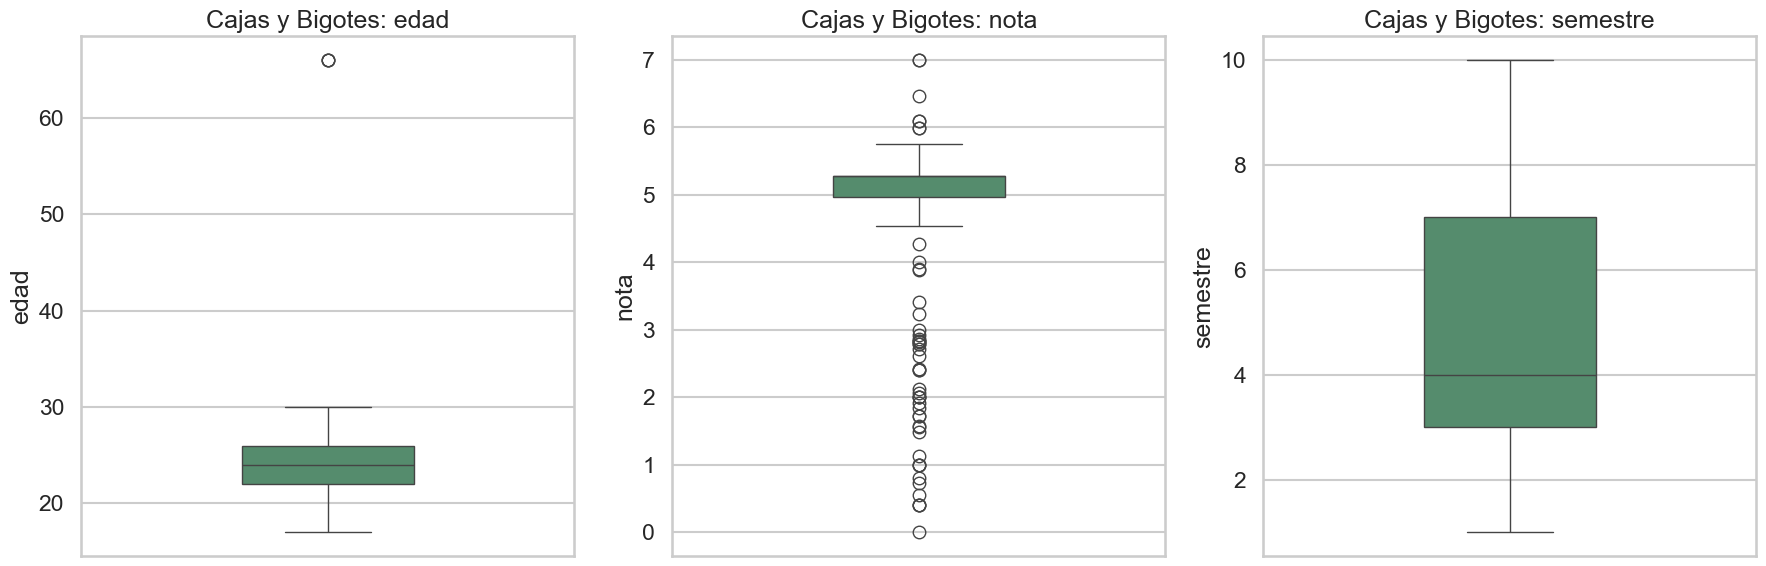

In [89]:
# Graficos de cajas y bigotes para detectar outliers en columnas numericas
import math
import matplotlib.pyplot as plt
import seaborn as sns

columnas_boxplot = ['edad', 'nota', 'semestre']
df_box = df.copy()
df_box['edad'] = pd.to_numeric(df_box['edad'], errors='coerce')
df_box['nota'] = pd.to_numeric(df_box['nota'], errors='coerce')
df_box['semestre'] = pd.to_numeric(df_box['semestre'], errors='coerce')

columnas_validas = [col for col in columnas_boxplot if df_box[col].notna().sum() > 0]

sns.set_theme(style='whitegrid', context='talk')
fig, axes = plt.subplots(1, len(columnas_validas), figsize=(6 * len(columnas_validas), 6))

if len(columnas_validas) == 1:
    axes = [axes]

for ax, columna in zip(axes, columnas_validas):
    sns.boxplot(y=df_box[columna], color='#4c956c', width=0.35, ax=ax)
    ax.set_title(f'Cajas y Bigotes: {columna}')
    ax.set_xlabel('')
    ax.set_ylabel(columna)

plt.tight_layout()
plt.show()
